# Predict Flight Price Machine Learning experiments & models

Leveraging historical and real-time data, this model aims to provide predictive insights on flight pricing trends, helping users make informed booking decisions.

In this notebook, we conduct:

- Exploratory Data Analysis (EDA): to understand key data characteristics and patterns.
- Feature Selection and Importance Analysis: to identify the most influential factors in predicting flight prices.
- Feature Scaling: to standardize data and enhance model performance.
- Model Comparison: evaluating the performance of ExtraTreesRegressor and XGBoost on key metrics to identify the best approach for price prediction.

In [1]:
!pip install imbalanced-learn

StatementMeta(, aae51fef-5185-4e14-a1e1-718a93030650, 3, Finished, Available, Finished)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 258.3/258.3 kB 9.8 MB/s eta 0:00:00


### Imports

In [2]:
from pyspark.sql import SparkSession
from pyspark.sql.types import ArrayType, StructType, StructField, StringType, IntegerType, MapType
from pyspark.sql import functions as F, Row
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import xgboost as xg

StatementMeta(, aae51fef-5185-4e14-a1e1-718a93030650, 4, Finished, Available, Finished)

### Read flights database

In [3]:
kustoUri = "https://trd-bgbxy2vkzr6knn6j4x.z7.kusto.fabric.microsoft.com"
accessToken = mssparkutils.credentials.getToken("kusto")
database = "flightRTI-Eventhouse"
table = "flights"

kustoQuery = "flights | extend ingestionTime = ingestion_time() | take 3000"
flights_details_df = spark.read\
    .format("com.microsoft.kusto.spark.synapse.datasource")\
    .option("accessToken", accessToken)\
    .option("kustoCluster", kustoUri)\
    .option("kustoDatabase", database)\
    .option("kustoQuery", kustoQuery).load()
display(flights_details_df.head())


StatementMeta(, aae51fef-5185-4e14-a1e1-718a93030650, 5, Finished, Available, Finished)

Row(departure_airport_name='Singapore Changi Airport', departure_airport_id='SIN', departure_airport_time='2024-11-15 19:40', arrival_airport_name='Chhatrapati Shivaji Maharaj International Airport Mumbai', arrival_airport_id='BOM', arrival_airport_time='2024-11-15 23:25', arrival_id='JED', departure_id='SIN', outbound_date='2024-11-15', duration=375, airplane='Airbus A321neo', airline='IndiGo', travel_class='Economy', flight_number='6E 1012', legroom='29 in', total_duration=810, price=435, type='One way', stops=2, booking_token='WyJDalJJVG5JMmFHWnVaMjg0YkhOQlEyOVNkMmRDUnkwdExTMHRMUzB0TFc5clltdDVNVUZCUVVGQlIyTnlXbmcwUm5SbWVVOUJFZ3MyUlRFd01USjhOa1U1TVJvTENPTFRBaEFDR2dOVlUwUTRISERpMHdJPSIsW1siU0lOIiwiMjAyNC0xMS0xNSIsIkJPTSIsbnVsbCwiNkUiLCIxMDEyIl0sWyJCT00iLCIyMDI0LTExLTE2IiwiSkVEIixudWxsLCI2RSIsIjkxIl1dXQ==', ingestionTime=datetime.datetime(2024, 11, 6, 12, 56, 16, 198266))

In [4]:
accessToken = mssparkutils.credentials.getToken("kusto")
kustoQuery = "process | sort by processed_ingestion_time desc | take 1"
process_df = spark.read\
    .format("com.microsoft.kusto.spark.synapse.datasource")\
    .option("accessToken", accessToken)\
    .option("kustoCluster", kustoUri)\
    .option("kustoDatabase", database)\
    .option("kustoQuery", kustoQuery).load()
display(process_df.head())

StatementMeta(, aae51fef-5185-4e14-a1e1-718a93030650, 6, Finished, Available, Finished)

Row(processed_ingestion_time=datetime.datetime(2024, 10, 30, 3, 26, 7, 265642))

### Data Preprocessing

In [5]:
pd_df_initial = flights_details_df.toPandas()
pd_df_initial.info()

StatementMeta(, aae51fef-5185-4e14-a1e1-718a93030650, 7, Finished, Available, Finished)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1432 entries, 0 to 1431
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   departure_airport_name  1432 non-null   object        
 1   departure_airport_id    1432 non-null   object        
 2   departure_airport_time  1432 non-null   object        
 3   arrival_airport_name    1432 non-null   object        
 4   arrival_airport_id      1432 non-null   object        
 5   arrival_airport_time    1432 non-null   object        
 6   arrival_id              1432 non-null   object        
 7   departure_id            1432 non-null   object        
 8   outbound_date           1432 non-null   object        
 9   duration                1432 non-null   int64         
 10  airplane                1432 non-null   object        
 11  airline                 1432 non-null   object        
 12  travel_class            1432 non-null   object  

In [6]:
last_ingestion_time = pd_df_initial['ingestionTime'].max()
last_ingestion_time

StatementMeta(, aae51fef-5185-4e14-a1e1-718a93030650, 8, Finished, Available, Finished)

Timestamp('2024-11-06 12:56:16.198266')

In [17]:
pd_df = pd_df_initial.sort_values('departure_airport_time').groupby('booking_token').agg(
    departure_airport_id=('departure_airport_id', 'first'),
    departure_airport_time=('departure_airport_time', 'first'),
    arrival_airport_id=('arrival_airport_id', 'last'),
    arrival_airport_time=('arrival_airport_time', 'last'),
    stops=('stops', 'first'),
    total_duration=('total_duration', 'first'),
    airline=('airline', 'first'),
    price=('price', 'first'),
    ingestion_time=('ingestionTime', 'first')
).reset_index()

pd_df = pd_df[pd_df.notnull().all(axis=1)]
pd_df.head()

StatementMeta(, aae51fef-5185-4e14-a1e1-718a93030650, 19, Finished, Available, Finished)

,booking_token,departure_airport_id,departure_airport_time,arrival_airport_id,arrival_airport_time,stops,total_duration,airline,price,ingestion_time
0,WyJDalJJT1hNeFkwUkVWMEo1ZUUxQlFWTnFaVUZDUnkwdE...,SIN,2024-11-13 17:00,JED,2024-11-13 21:30,1,570,Saudia,579.0,2024-10-30 03:21:19.941520
1,WyJDalJJT1hNeFkwUkVWMEo1ZUUxQlFWTnFaVUZDUnkwdE...,SIN,2024-11-13 02:30,JED,2024-11-13 09:20,2,710,Emirates,849.0,2024-10-30 03:21:26.626796
2,WyJDalJJT1hNeFkwUkVWMEo1ZUUxQlFWTnFaVUZDUnkwdE...,SIN,2024-11-13 19:25,JED,2024-11-15 00:05,2,2020,Etihad,428.0,2024-10-30 03:21:26.626796
3,WyJDalJJT1hNeFkwUkVWMEo1ZUUxQlFWTnFaVUZDUnkwdE...,SIN,2024-11-13 02:00,JED,2024-11-13 12:50,2,950,Ethiopian,521.0,2024-10-30 03:21:26.626796
4,WyJDalJJT1hNeFkwUkVWMEo1ZUUxQlFWTnFaVUZDUnkwdE...,SIN,2024-11-13 20:25,JED,2024-11-14 04:10,2,765,Gulf Air,558.0,2024-10-30 03:21:19.941520


In [18]:
current_pd_df = pd_df[pd_df['ingestion_time'] > last_ingestion_time]
current_pd_df.head()

StatementMeta(, aae51fef-5185-4e14-a1e1-718a93030650, 20, Finished, Available, Finished)

,booking_token,departure_airport_id,departure_airport_time,arrival_airport_id,arrival_airport_time,stops,total_duration,airline,price,ingestion_time


In [19]:
pd_df = pd_df.drop(columns=['ingestion_time'])

if len(current_pd_df.head(1)) > 0:
    spark = SparkSession.builder.getOrCreate()
    visualization_df = spark.createDataFrame(current_pd_df)
    visualization_table = 'flightVisualization'
    visualization_df.write.format("com.microsoft.kusto.spark.synapse.datasource").\
        option("kustoCluster",kustoUri).\
        option("kustoDatabase",database).\
        option("kustoTable", visualization_table).\
        option("accessToken", accessToken).\
        option("tableCreateOptions", "CreateIfNotExist").mode("Append").save()

StatementMeta(, aae51fef-5185-4e14-a1e1-718a93030650, 21, Finished, Available, Finished)

### Exploratory Data Analysis

StatementMeta(, aae51fef-5185-4e14-a1e1-718a93030650, 22, Finished, Available, Finished)

<Axes: >

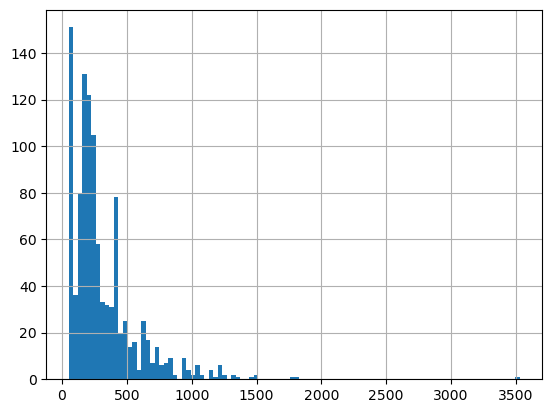

In [20]:
pd_df['price'].hist(bins=100)

StatementMeta(, aae51fef-5185-4e14-a1e1-718a93030650, 23, Finished, Available, Finished)

/home/trusted-service-user/cluster-env/trident_env/lib/python3.11/site-packages/seaborn/categorical.py:1794: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/trusted-service-user/cluster-env/trident_env/lib/python3.11/site-packages/seaborn/categorical.py:1794: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/trusted-service-user/cluster-env/trident_env/lib/python3.11/site-packages/seaborn/categorical.py:1794: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/trusted-service-user/cluster-env/trident_env/lib/python3.11/site-packages/se

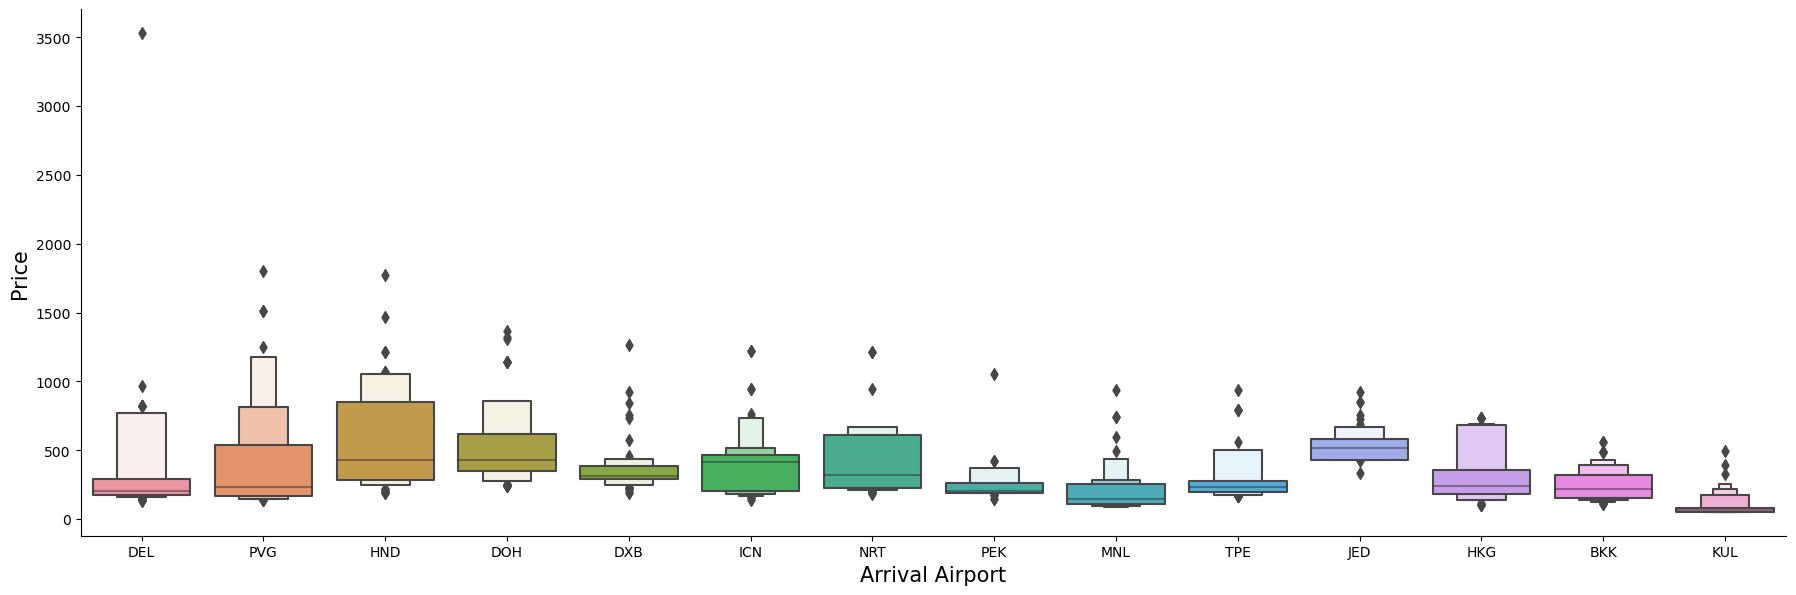

In [21]:
sns.catplot(y = 'price', x = 'arrival_airport_id', data = pd_df.sort_values('price', ascending=False),kind='boxen',height = 6, aspect = 3)
plt.xlabel('Arrival Airport',size=15)
plt.ylabel('Price',size=15)
plt.show()

StatementMeta(, aae51fef-5185-4e14-a1e1-718a93030650, 24, Finished, Available, Finished)

/home/trusted-service-user/cluster-env/trident_env/lib/python3.11/site-packages/seaborn/categorical.py:1794: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/trusted-service-user/cluster-env/trident_env/lib/python3.11/site-packages/seaborn/categorical.py:1794: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/trusted-service-user/cluster-env/trident_env/lib/python3.11/site-packages/seaborn/categorical.py:1794: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/trusted-service-user/cluster-env/trident_env/lib/python3.11/site-packages/se

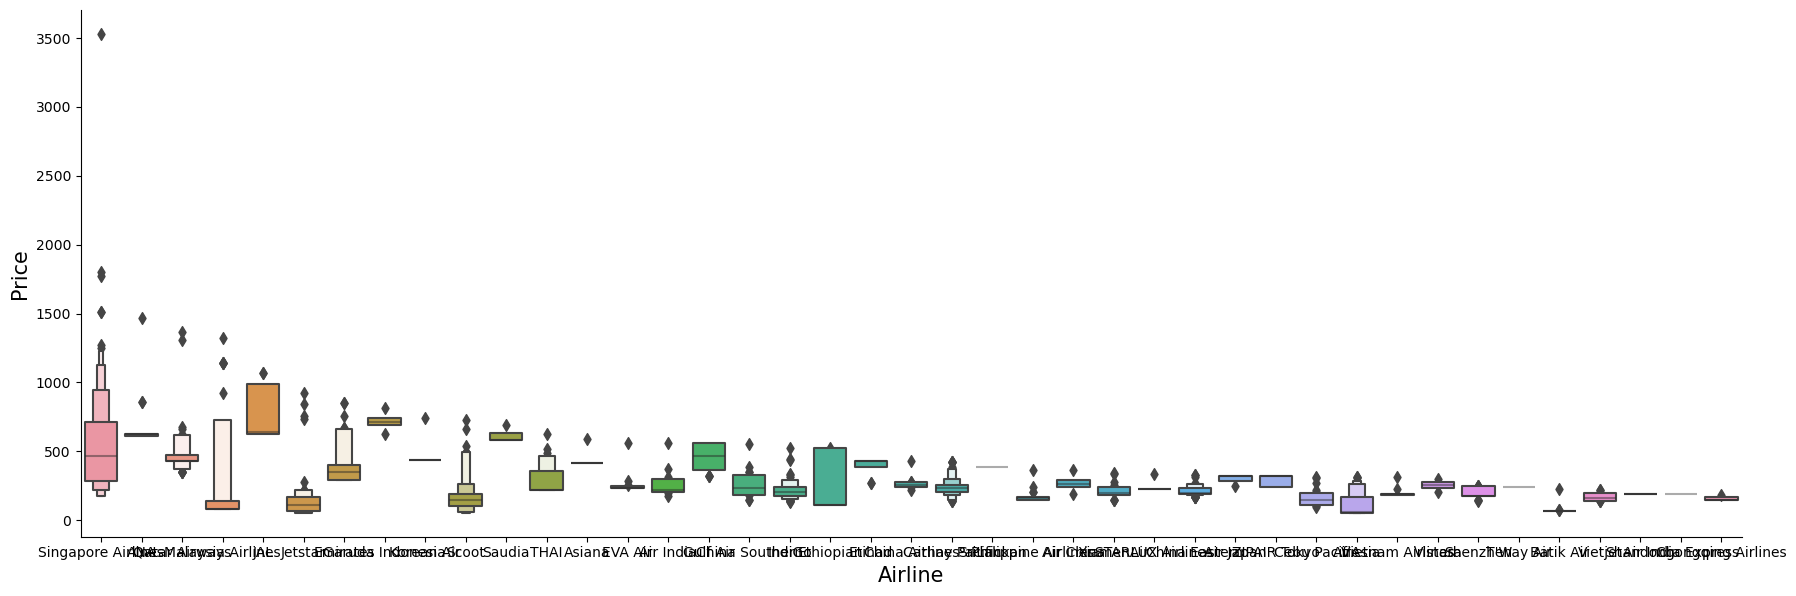

In [22]:
# Airline vs Price
sns.catplot(y = 'price', x = 'airline', data = pd_df.sort_values('price', ascending=False),kind='boxen',height = 6, aspect = 3)
plt.xlabel('Airline',size=15)
plt.ylabel('Price',size=15)
plt.show()

In [23]:
pd_df['departure_airport_day'] = pd.to_datetime(pd_df['departure_airport_time']).dt.day
pd_df['departure_airport_month'] = pd.to_datetime(pd_df['departure_airport_time']).dt.month
pd_df['departure_airport_hour'] = pd.to_datetime(pd_df['departure_airport_time']).dt.hour
pd_df['departure_airport_min'] = pd.to_datetime(pd_df['departure_airport_time']).dt.minute
pd_df['arrival_airport_day'] = pd.to_datetime(pd_df['arrival_airport_time']).dt.day
pd_df['arrival_airport_month'] = pd.to_datetime(pd_df['arrival_airport_time']).dt.month
pd_df['arrival_airport_hour'] = pd.to_datetime(pd_df['arrival_airport_time']).dt.hour
pd_df['arrival_airport_min'] = pd.to_datetime(pd_df['arrival_airport_time']).dt.minute

StatementMeta(, aae51fef-5185-4e14-a1e1-718a93030650, 25, Finished, Available, Finished)

In [24]:
Airline = pd_df['airline']
Airline = pd.get_dummies(Airline, dtype=int)
Airline.head()

StatementMeta(, aae51fef-5185-4e14-a1e1-718a93030650, 26, Finished, Available, Finished)

,ANA,Air China,Air India,Air India Express,Air Japan,AirAsia,Asiana,Batik Air,Cathay Pacific,Cebu Pacific,...,Shenzhen,Singapore Airlines,SriLankan,T'Way Air,THAI,Vietjet,Vietnam Airlines,Vistara,XiamenAir,ZIPAIR Tokyo
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [25]:
list1 = ['departure_airport_id', 'arrival_airport_id']
for l in list1:
    print(pd_df[[l]].value_counts(), '\n')

StatementMeta(, aae51fef-5185-4e14-a1e1-718a93030650, 27, Finished, Available, Finished)

departure_airport_id
SIN                     1068
Name: count, dtype: int64 

arrival_airport_id
KUL                   191
BKK                   106
ICN                    83
HKG                    80
MNL                    78
PVG                    65
NRT                    63
DEL                    63
HND                    63
TPE                    60
DOH                    56
DXB                    54
JED                    53
PEK                    53
Name: count, dtype: int64 



In [26]:
Airport = pd_df[['departure_airport_id', 'arrival_airport_id']]
Airport = pd.get_dummies(Airport, columns=['departure_airport_id', 'arrival_airport_id'], dtype=int)
Airport.head()

StatementMeta(, aae51fef-5185-4e14-a1e1-718a93030650, 28, Finished, Available, Finished)

,departure_airport_id_SIN,arrival_airport_id_BKK,arrival_airport_id_DEL,arrival_airport_id_DOH,arrival_airport_id_DXB,arrival_airport_id_HKG,arrival_airport_id_HND,arrival_airport_id_ICN,arrival_airport_id_JED,arrival_airport_id_KUL,arrival_airport_id_MNL,arrival_airport_id_NRT,arrival_airport_id_PEK,arrival_airport_id_PVG,arrival_airport_id_TPE
0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0
4,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0


In [27]:
selection_pd_df = pd_df[['stops', 'price','total_duration', 'departure_airport_hour','departure_airport_min','arrival_airport_hour','arrival_airport_min', 'departure_airport_day', 'arrival_airport_month', 'arrival_airport_day' ]]

StatementMeta(, aae51fef-5185-4e14-a1e1-718a93030650, 29, Finished, Available, Finished)

In [28]:
final_pd_df = pd.concat([selection_pd_df, Airline, Airport], axis = 1)
final_pd_df.head()

StatementMeta(, aae51fef-5185-4e14-a1e1-718a93030650, 30, Finished, Available, Finished)

,stops,price,total_duration,departure_airport_hour,departure_airport_min,arrival_airport_hour,arrival_airport_min,departure_airport_day,arrival_airport_month,arrival_airport_day,...,arrival_airport_id_HKG,arrival_airport_id_HND,arrival_airport_id_ICN,arrival_airport_id_JED,arrival_airport_id_KUL,arrival_airport_id_MNL,arrival_airport_id_NRT,arrival_airport_id_PEK,arrival_airport_id_PVG,arrival_airport_id_TPE
0,1,579.0,570,17,0,21,30,13,11,13,...,0,0,0,1,0,0,0,0,0,0
1,2,849.0,710,2,30,9,20,13,11,13,...,0,0,0,1,0,0,0,0,0,0
2,2,428.0,2020,19,25,0,5,13,11,15,...,0,0,0,1,0,0,0,0,0,0
3,2,521.0,950,2,0,12,50,13,11,13,...,0,0,0,1,0,0,0,0,0,0
4,2,558.0,765,20,25,4,10,13,11,14,...,0,0,0,1,0,0,0,0,0,0


### Feature Selection/Importance

In [29]:
final_pd_df.shape

StatementMeta(, aae51fef-5185-4e14-a1e1-718a93030650, 31, Finished, Available, Finished)

(1068, 66)

In [30]:
final_pd_df.columns

StatementMeta(, aae51fef-5185-4e14-a1e1-718a93030650, 32, Finished, Available, Finished)

Index(['stops', 'price', 'total_duration', 'departure_airport_hour',
       'departure_airport_min', 'arrival_airport_hour', 'arrival_airport_min',
       'departure_airport_day', 'arrival_airport_month', 'arrival_airport_day',
       'ANA', 'Air China', 'Air India', 'Air India Express', 'Air Japan',
       'AirAsia', 'Asiana', 'Batik Air', 'Cathay Pacific', 'Cebu Pacific',
       'China Airlines', 'China Eastern', 'China Southern',
       'Chongqing Airlines', 'EVA Air', 'Emirates', 'Ethiopian', 'Etihad',
       'Garuda Indonesia', 'Gulf Air', 'IndiGo', 'JAL', 'Jetstar',
       'Korean Air', 'Malaysia Airlines', 'Philippine Airlines',
       'Qatar Airways', 'STARLUX Airlines', 'Saudia', 'Scoot', 'Shandong',
       'Shenzhen', 'Singapore Airlines', 'SriLankan', 'T'Way Air', 'THAI',
       'Vietjet', 'Vietnam Airlines', 'Vistara', 'XiamenAir', 'ZIPAIR Tokyo',
       'departure_airport_id_SIN', 'arrival_airport_id_BKK',
       'arrival_airport_id_DEL', 'arrival_airport_id_DOH',
       '

StatementMeta(, aae51fef-5185-4e14-a1e1-718a93030650, 33, Finished, Available, Finished)

/home/trusted-service-user/cluster-env/trident_env/lib/python3.11/site-packages/seaborn/matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


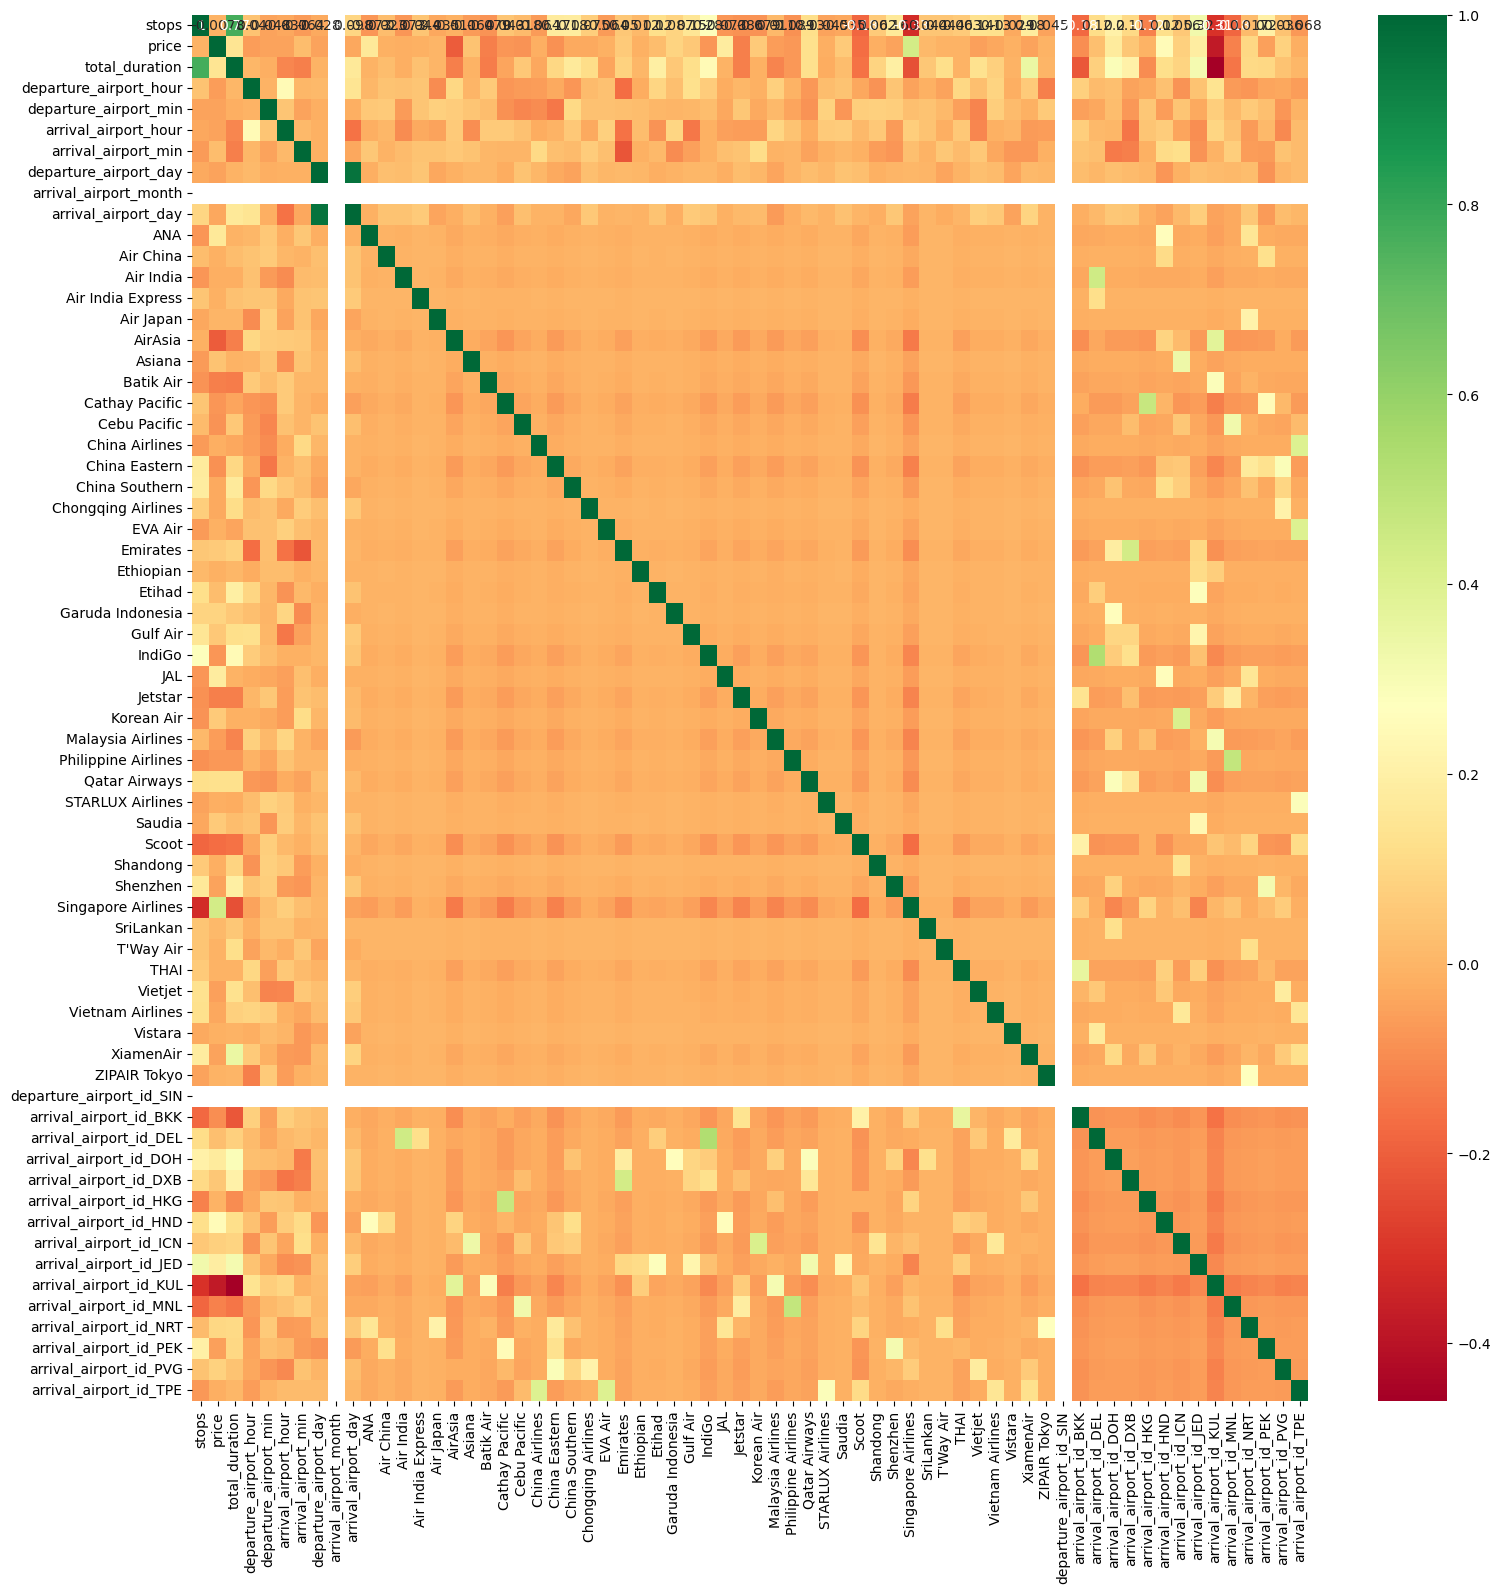

In [31]:
plt.figure(figsize = (18, 18))
sns.heatmap(final_pd_df.corr(), annot = True, cmap = 'RdYlGn')

plt.show()


In [32]:
X = final_pd_df.copy(deep=True)
X.drop(['price'],axis=1,inplace=True)
X.head()

StatementMeta(, aae51fef-5185-4e14-a1e1-718a93030650, 34, Finished, Available, Finished)

,stops,total_duration,departure_airport_hour,departure_airport_min,arrival_airport_hour,arrival_airport_min,departure_airport_day,arrival_airport_month,arrival_airport_day,ANA,...,arrival_airport_id_HKG,arrival_airport_id_HND,arrival_airport_id_ICN,arrival_airport_id_JED,arrival_airport_id_KUL,arrival_airport_id_MNL,arrival_airport_id_NRT,arrival_airport_id_PEK,arrival_airport_id_PVG,arrival_airport_id_TPE
0,1,570,17,0,21,30,13,11,13,0,...,0,0,0,1,0,0,0,0,0,0
1,2,710,2,30,9,20,13,11,13,0,...,0,0,0,1,0,0,0,0,0,0
2,2,2020,19,25,0,5,13,11,15,0,...,0,0,0,1,0,0,0,0,0,0
3,2,950,2,0,12,50,13,11,13,0,...,0,0,0,1,0,0,0,0,0,0
4,2,765,20,25,4,10,13,11,14,0,...,0,0,0,1,0,0,0,0,0,0


In [33]:
y = final_pd_df.iloc[:, 1]
y.head()

StatementMeta(, aae51fef-5185-4e14-a1e1-718a93030650, 35, Finished, Available, Finished)

0    579.0
1    849.0
2    428.0
3    521.0
4    558.0
Name: price, dtype: float64

In [34]:
final_pd_df.corr()

StatementMeta(, aae51fef-5185-4e14-a1e1-718a93030650, 36, Finished, Available, Finished)

,stops,price,total_duration,departure_airport_hour,departure_airport_min,arrival_airport_hour,arrival_airport_min,departure_airport_day,arrival_airport_month,arrival_airport_day,...,arrival_airport_id_HKG,arrival_airport_id_HND,arrival_airport_id_ICN,arrival_airport_id_JED,arrival_airport_id_KUL,arrival_airport_id_MNL,arrival_airport_id_NRT,arrival_airport_id_PEK,arrival_airport_id_PVG,arrival_airport_id_TPE
stops,1.000000,-0.007840,0.768615,0.039937,-0.048223,-0.036738,-0.063826,-0.027675,NaN,0.098365,...,-0.120688,0.124461,0.056229,0.324764,-0.307095,-0.184708,0.017037,0.199257,0.036066,-0.067544
price,-0.007840,1.000000,0.148110,-0.061028,-0.048320,-0.044349,0.019502,-0.046546,NaN,-0.033302,...,-0.006064,0.251690,0.075736,0.188522,-0.377876,-0.120967,0.100072,-0.051310,0.084099,-0.020321
total_duration,0.768615,0.148110,1.000000,0.002671,-0.020790,-0.111467,-0.129624,-0.006352,NaN,0.161763,...,-0.096177,0.124261,0.089196,0.310514,-0.460671,-0.149809,0.106804,0.102548,0.039825,0.004736
departure_airport_hour,0.039937,-0.061028,0.002671,1.000000,-0.007439,0.241798,0.002362,0.008843,NaN,0.147618,...,-0.030800,0.034467,-0.079305,0.039816,0.139707,-0.065051,-0.072780,-0.039303,-0.037255,-0.058230
departure_airport_min,-0.048223,-0.048320,-0.020790,-0.007439,1.000000,0.045425,-0.048360,-0.018778,NaN,-0.018980,...,0.049891,-0.059260,0.045162,-0.028557,0.070645,0.007246,0.062632,0.025597,-0.073128,-0.009782
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
arrival_airport_id_MNL,-0.184708,-0.120967,-0.149809,-0.065051,0.007246,0.030787,0.074316,0.009717,NaN,-0.027618,...,-0.079872,-0.070278,-0.081480,-0.064141,-0.130993,1.000000,-0.070278,-0.064141,-0.071456,-0.068482
arrival_airport_id_NRT,0.017037,0.100072,0.106804,-0.072780,0.062632,-0.063679,-0.055992,0.022171,NaN,0.050437,...,-0.071245,-0.062687,-0.072679,-0.057213,-0.116843,-0.070278,1.000000,-0.057213,-0.063737,-0.061085
arrival_airport_id_PEK,0.199257,-0.051310,0.102548,-0.039303,0.025597,0.010694,-0.065650,-0.081439,NaN,-0.064426,...,-0.065024,-0.057213,-0.066332,-0.052217,-0.106640,-0.064141,-0.057213,1.000000,-0.058172,-0.055751
arrival_airport_id_PVG,0.036066,0.084099,0.039825,-0.037255,-0.073128,-0.102877,0.036837,0.000047,NaN,0.022397,...,-0.072439,-0.063737,-0.073897,-0.058172,-0.118802,-0.071456,-0.063737,-0.058172,1.000000,-0.062109


In [35]:
from sklearn.ensemble import ExtraTreesRegressor

selection = ExtraTreesRegressor()
selection.fit(X, y)

StatementMeta(, aae51fef-5185-4e14-a1e1-718a93030650, 37, Finished, Available, Finished)

ExtraTreesRegressor()

In [36]:
print(selection.feature_importances_)

StatementMeta(, aae51fef-5185-4e14-a1e1-718a93030650, 38, Finished, Available, Finished)

[4.91626961e-03 7.49790694e-02 3.16144483e-02 1.24094525e-02
 3.22007314e-02 2.28815567e-02 6.29133447e-02 0.00000000e+00
 6.05389006e-02 3.80096649e-02 5.54815350e-05 7.20243569e-04
 1.68864212e-07 8.36918320e-06 3.22058336e-04 5.76941076e-03
 1.65497610e-05 1.38526779e-03 6.96440140e-06 5.94460060e-05
 3.20507182e-04 4.58175476e-04 3.08477503e-06 9.88377532e-05
 4.04442924e-03 9.72251636e-05 3.24994841e-04 5.65880420e-03
 5.58100713e-04 1.25788269e-03 4.09383214e-02 1.28048212e-02
 9.29537313e-03 3.09494951e-02 5.06129148e-04 2.58640754e-03
 1.62233887e-05 1.49566427e-04 4.65480951e-03 1.05739325e-06
 1.05976328e-04 1.86294997e-01 2.23193601e-05 1.71131821e-06
 1.60258048e-03 3.75273131e-05 2.14346537e-05 1.44588048e-05
 4.28909752e-05 5.66706591e-06 0.00000000e+00 2.15371285e-03
 2.95694010e-02 4.34990617e-02 1.23979941e-02 2.20288191e-03
 3.39733706e-02 3.84788187e-03 4.13297075e-02 1.32478195e-01
 4.59386661e-03 1.28876247e-02 7.19882610e-03 2.04614004e-02
 1.72486687e-03]


### Feature Scaling

In [37]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_pd_df = scaler.fit_transform(X)

scaled_pd_df.shape

StatementMeta(, aae51fef-5185-4e14-a1e1-718a93030650, 39, Finished, Available, Finished)

(1068, 65)

In [38]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.30,random_state=123)
x_train.shape,x_test.shape,y_train.shape,y_test.shape

StatementMeta(, aae51fef-5185-4e14-a1e1-718a93030650, 40, Finished, Available, Finished)

((747, 65), (321, 65), (747,), (321,))

### ExtraTreesRegressor Model

In [39]:
import mlflow
import mlflow.sklearn
from mlflow.models.signature import infer_signature
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split


def metrics(y_true, y_pred):
    return {
        'RMSE': mean_squared_error(y_true, y_pred) ** 0.5,
        'R_Squared_Value': r2_score(y_true, y_pred),
        'Accuracy': accuracy(y_true, y_pred)
    }

def accuracy(y_true, y_pred):
    errors = abs(y_true - y_pred)
    mape = 100 * np.mean(errors/y_true)
    accuracy = 100 - mape
    return accuracy

x_train,x_test,y_train,y_test=train_test_split(
    X, y, test_size=0.3, random_state=123
)


StatementMeta(, aae51fef-5185-4e14-a1e1-718a93030650, 41, Finished, Available, Finished)

In [40]:
with mlflow.start_run() as run:
    # Log parameters and metrics using the MLflow APIs
    print("Log params")
    params = {}
    mlflow.log_params(params)
    etr = ExtraTreesRegressor(**params)
    etr.fit(x_train, y_train)
    y_pred = etr.predict(x_test)

    print("Log metrics")
    mlflow.log_metrics(metrics(y_test, y_pred))

    # Log the sklearn model and register as version 1
    print("Log model")
    signature = infer_signature(X, y)
    mlflow.sklearn.log_model(
        sk_model=etr,
        artifact_path="flightML",
        input_example=x_train,
        registered_model_name="sk-learn-extra-trees-regression-model",
        signature=signature
    )

    # Register the model produced from your training job.
    print("Register_model.")
    mlflow.register_model(
        "runs:/{}/flightML".format(run.info.run_id), "sk-learn-extra-trees-regression-model"
    )
    print("All done")

StatementMeta(, aae51fef-5185-4e14-a1e1-718a93030650, 42, Finished, Available, Finished)

Log params
Log metrics
Log model
Register_model.
All done


/home/trusted-service-user/cluster-env/trident_env/lib/python3.11/site-packages/mlflow/types/utils.py:394: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
Registered model 'sk-learn-extra-trees-regression-model' already exists. Creating a new version of this model...
2024/11/07 12:41:35 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds 

In [41]:
metrics(y_test, y_pred)

StatementMeta(, aae51fef-5185-4e14-a1e1-718a93030650, 43, Finished, Available, Finished)

{'RMSE': 191.65869635656134,
 'R_Squared_Value': 0.6164548498061038,
 'Accuracy': 85.35180538883762}

### XGBoost Model

In [42]:
xgb_r = xg.XGBRegressor(objective ='reg:linear',n_estimators = 10, seed = 123)
xgb_r.fit(x_train, y_train)
pred = xgb_r.predict(x_test)
metrics(y_test, pred)

StatementMeta(, aae51fef-5185-4e14-a1e1-718a93030650, 44, Finished, Available, Finished)

/home/trusted-service-user/cluster-env/trident_env/lib/python3.11/site-packages/xgboost/core.py:160: UserWarning: [12:41:42] WARNING: /croot/xgboost-split_1713972711803/work/cpp_src/src/objective/regression_obj.cu:209: reg:linear is now deprecated in favor of reg:squarederror.
  warnings.warn(smsg, UserWarning)


{'RMSE': 203.22380318399027,
 'R_Squared_Value': 0.5687703785058138,
 'Accuracy': 78.64473802328568}

StatementMeta(, aae51fef-5185-4e14-a1e1-718a93030650, 45, Finished, Available, Finished)

/tmp/ipykernel_7014/3860349970.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_test-pred)
/home/trusted-service-user/cluster-env/trident_env/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


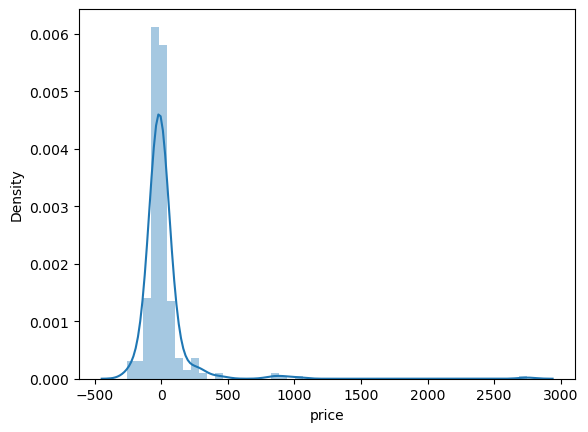

In [43]:
sns.distplot(y_test-pred)
plt.show()

### Write database

In [44]:
process_pd_df = pd.DataFrame(columns=['processed_ingestion_time'])
process_pd_df['processed_ingestion_time'] = [last_ingestion_time]

spark = SparkSession.builder.getOrCreate()
process_df = spark.createDataFrame(process_pd_df)

process_table = 'process'
process_df.write.format("com.microsoft.kusto.spark.synapse.datasource").\
    option("kustoCluster",kustoUri).\
    option("kustoDatabase",database).\
    option("kustoTable", process_table).\
    option("accessToken", accessToken).\
    option("tableCreateOptions", "CreateIfNotExist").mode("Append").save()

StatementMeta(, aae51fef-5185-4e14-a1e1-718a93030650, 46, Finished, Available, Finished)